In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from pathlib import Path



# ── Datensatz laden ───────────────────────────────────────────────────────
DATA_PATH = Path("sampleProj/heart_disease_uci.csv")

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nErste 5 Zeilen:")
print(df.head())

print("\nDatentypen:")
print(df.dtypes)

print("\nFehlende Werte:")
print(df.isnull().sum())   

print("\nZielklassen-Verteilung:")
print(df["sex"].value_counts())


spalten_erklaerung = {
    "id":       "Patienten-ID (brauchen wir nicht)",
    "age":      "Alter in Jahren",
    "sex":      "Geschlecht: Male / Female",
    "dataset":  "Herkunft: Cleveland, Hungary, etc. (brauchen wir nicht)",
    "cp":       "Brustschmerztyp: typical angina, atypical, non-anginal, asymptomatic",
    "trestbps": "Blutdruck in Ruhe (mmHg)",
    "chol":     "Cholesterin (mg/dl)",
    "fbs":      "Nüchternblutzucker > 120: True/False",
    "restecg":  "EKG-Ergebnis: normal, lv hypertrophy, st-t abnormality",
    "thalch":   "Maximale Herzfrequenz",
    "exang":    "Belastungsangina: True/False",
    "oldpeak":  "ST-Depression durch Belastung",
    "slope":    "Steigung der ST-Kurve: upsloping, flat, downsloping",
    "ca":       "Anzahl größerer Gefäße (0-3)",
    "thal":     "Thalassämie: normal, fixed defect, reversable defect",
    "num":      "ZIELVARIABLE: 0=gesund, 1-4=Herzerkrankung (Schweregrad)"
}

for k, v in spalten_erklaerung.items():
    print(f"{k:>10}: {v}")

Shape: (920, 16)

Erste 5 Zeilen:
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4 

In [30]:
print("\nVerteilung der Zielvariable 'num':")
print(df["num"].value_counts().sort_index())


Verteilung der Zielvariable 'num':
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


In [31]:
# Wir machen eine BINÄRE Klassifikation: gesund vs. krank
# 0 bleibt 0, alles > 0 wird zu 1

df["target"] = (df["num"] > 0).astype(int)


print("\nNach Binarisierung:")
print(df["target"].value_counts())
print(f"Anteil krank: {df['target'].mean():.1%}")


Nach Binarisierung:
target
1    509
0    411
Name: count, dtype: int64
Anteil krank: 55.3%


In [32]:
print("Fehlende Werte pro Spalte:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_info = pd.DataFrame({"Anzahl": missing, "Prozent": missing_pct})
print(missing_info[missing_info["Anzahl"] > 0])


df = df.drop(columns=["id", "dataset", "num", "ca", "thal"])

print("\nNach dem Entfernen:", df.shape)

Fehlende Werte pro Spalte:
          Anzahl  Prozent
trestbps      59      6.4
chol          30      3.3
fbs           90      9.8
restecg        2      0.2
thalch        55      6.0
exang         55      6.0
oldpeak       62      6.7
slope        309     33.6
ca           611     66.4
thal         486     52.8

Nach dem Entfernen: (920, 12)


In [33]:
# ── Fehlende Werte auffüllen ──────────────────────────────────────────────

# Numerische Spalten → mit Median auffüllen
# (Median ist robuster als Mittelwert bei Ausreißern)
num_cols = ["trestbps", "chol", "thalch", "oldpeak"]
for col in num_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"{col}: fehlende Werte mit Median {median_val:.1f} aufgefüllt")

# Kategorische Spalten → mit häufigstem Wert (Modus) auffüllen
cat_cols = ["fbs", "restecg", "exang", "slope"]
for col in cat_cols:
    modus_val = df[col].mode()[0]
    df[col] = df[col].fillna(modus_val)
    print(f"{col}: fehlende Werte mit '{modus_val}' aufgefüllt")

print("\nFehlende Werte nach Behandlung:")
print(df.isnull().sum().sum(), "fehlende Werte verbleiben")

trestbps: fehlende Werte mit Median 130.0 aufgefüllt
chol: fehlende Werte mit Median 223.0 aufgefüllt
thalch: fehlende Werte mit Median 140.0 aufgefüllt
oldpeak: fehlende Werte mit Median 0.5 aufgefüllt
fbs: fehlende Werte mit 'False' aufgefüllt
restecg: fehlende Werte mit 'normal' aufgefüllt
exang: fehlende Werte mit 'False' aufgefüllt
slope: fehlende Werte mit 'flat' aufgefüllt

Fehlende Werte nach Behandlung:
0 fehlende Werte verbleiben


/tmp/ipykernel_1271402/485884118.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(modus_val)


In [34]:
# Kategorische Spalten (Text) müssen zu Zahlen werden
# Zwei Methoden:

# ── Methode A: Label Encoding (für binäre Spalten) ────────────────────────
# sex: Male/Female → 1/0
# fbs, exang: True/False → 1/0
df["sex"]   = (df["sex"] == "Male").astype(int)
df["fbs"]   = (df["fbs"] == True).astype(int)
df["exang"] = (df["exang"] == True).astype(int)

print("Spalten nach Encoding:")
print(df.columns.tolist())
print("\nShape:", df.shape)
print("\nErste Zeile:")
print(df.iloc[0])

Spalten nach Encoding:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'target']

Shape: (920, 12)

Erste Zeile:
age                     63
sex                      1
cp          typical angina
trestbps             145.0
chol                 233.0
fbs                      1
restecg     lv hypertrophy
thalch               150.0
exang                    0
oldpeak                2.3
slope          downsloping
target                   0
Name: 0, dtype: object


Gefundene sex-Werte: [np.int64(0), np.int64(1)]
Gesund pro Gruppe: [144, 267]
Krank  pro Gruppe: [50, 459]


/tmp/ipykernel_1271402/1749191739.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,2].boxplot([chol_gesund, chol_krank], labels=["Gesund", "Krank"])


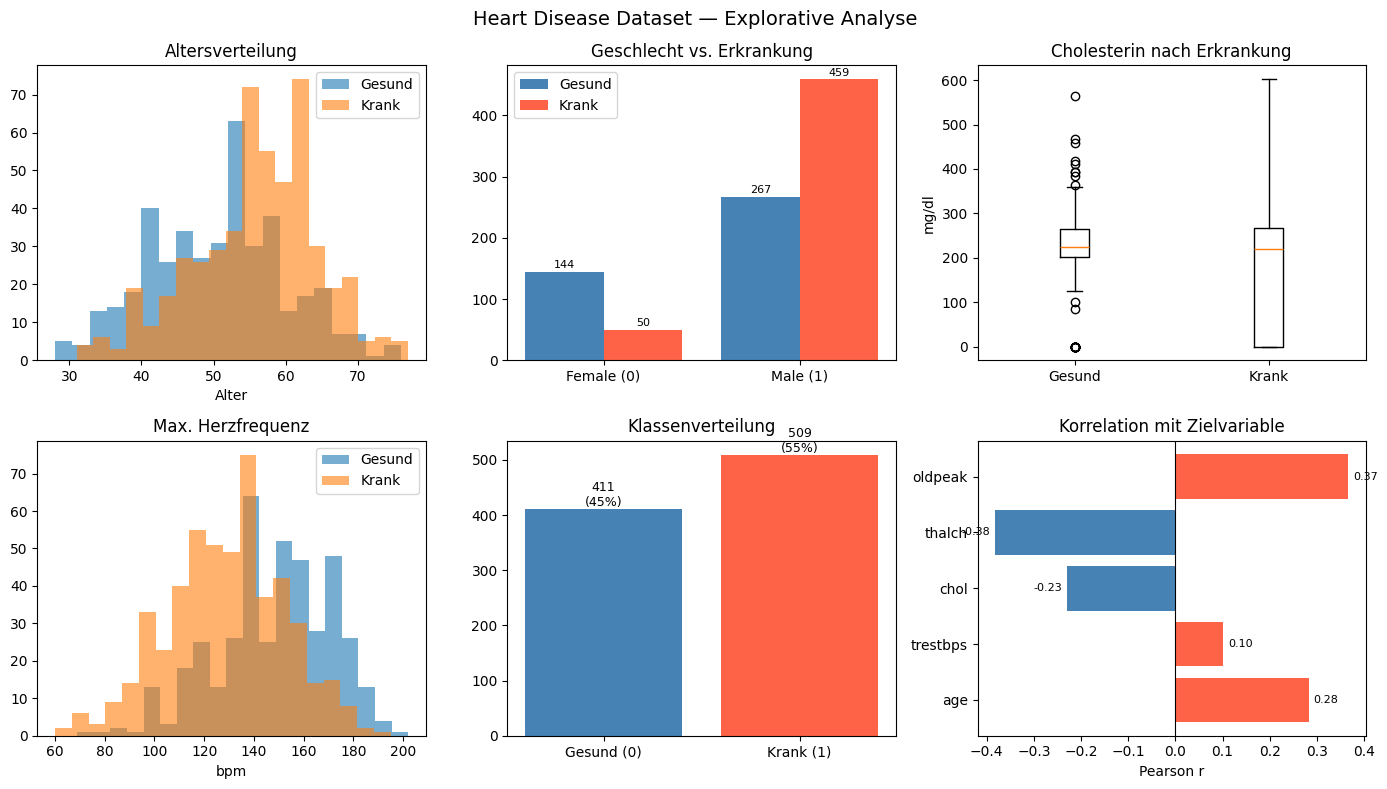

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Heart Disease Dataset — Explorative Analyse", fontsize=14)

# ── Altersverteilung nach Erkrankung ─────────────────────────────────────
axes[0,0].hist(df[df["target"]==0]["age"], alpha=0.6, label="Gesund", bins=20)
axes[0,0].hist(df[df["target"]==1]["age"], alpha=0.6, label="Krank",  bins=20)
axes[0,0].set_title("Altersverteilung")
axes[0,0].set_xlabel("Alter")
axes[0,0].legend()

# ── Geschlecht vs. Erkrankung — KOMPLETT NEU ──────────────────────────────
# Sicher zählen: direkt aus dem originalen y_train/y_test können wir
# nicht mehr zurück. Wir nutzen die numerischen Werte direkt.

# sex-Werte holen — egal ob 0/1 oder True/False
sex_vals = sorted(df["sex"].unique())
print("Gefundene sex-Werte:", sex_vals)   # Debug-Ausgabe

# Für jeden gefundenen Wert zählen
gesund_counts = []
krank_counts  = []
for val in sex_vals:
    gesund_counts.append(len(df[(df["sex"]==val) & (df["target"]==0)]))
    krank_counts.append( len(df[(df["sex"]==val) & (df["target"]==1)]))

print("Gesund pro Gruppe:", gesund_counts)  # Debug-Ausgabe
print("Krank  pro Gruppe:", krank_counts)   # Debug-Ausgabe

# Labels anpassen — je nachdem was in sex_vals steht
if len(sex_vals) == 2:
    x_labels = ["Female (0)", "Male (1)"]
else:
    x_labels = [str(v) for v in sex_vals]

x = np.arange(len(sex_vals))
b1 = axes[0,1].bar(x - 0.2, gesund_counts, width=0.4,
                    label="Gesund", color="steelblue")
b2 = axes[0,1].bar(x + 0.2, krank_counts,  width=0.4,
                    label="Krank",  color="tomato")

# Zahlenwerte über die Balken schreiben
for bar in b1:
    h = bar.get_height()
    if h > 0:
        axes[0,1].text(bar.get_x() + bar.get_width()/2, h + 3,
                       str(int(h)), ha="center", va="bottom", fontsize=8)
for bar in b2:
    h = bar.get_height()
    if h > 0:
        axes[0,1].text(bar.get_x() + bar.get_width()/2, h + 3,
                       str(int(h)), ha="center", va="bottom", fontsize=8)

axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(x_labels)
axes[0,1].set_title("Geschlecht vs. Erkrankung")
axes[0,1].legend()

# ── Cholesterin ───────────────────────────────────────────────────────────
chol_gesund = df[df["target"]==0]["chol"].dropna()
chol_krank  = df[df["target"]==1]["chol"].dropna()
axes[0,2].boxplot([chol_gesund, chol_krank], labels=["Gesund", "Krank"])
axes[0,2].set_title("Cholesterin nach Erkrankung")
axes[0,2].set_ylabel("mg/dl")

# ── Maximale Herzfrequenz ─────────────────────────────────────────────────
axes[1,0].hist(df[df["target"]==0]["thalch"].dropna(),
               alpha=0.6, label="Gesund", bins=20)
axes[1,0].hist(df[df["target"]==1]["thalch"].dropna(),
               alpha=0.6, label="Krank",  bins=20)
axes[1,0].set_title("Max. Herzfrequenz")
axes[1,0].set_xlabel("bpm")
axes[1,0].legend()

# ── Klassenverteilung ─────────────────────────────────────────────────────
counts = df["target"].value_counts().sort_index()
balken = axes[1,1].bar(["Gesund (0)", "Krank (1)"],
                        counts.values,
                        color=["steelblue","tomato"])
axes[1,1].set_title("Klassenverteilung")
for i, v in enumerate(counts.values):
    axes[1,1].text(i, v + 5, f"{v}\n({v/len(df):.0%})",
                   ha="center", fontsize=9)

# ── Korrelation mit Zielvariable ──────────────────────────────────────────
num_features = ["age", "trestbps", "chol", "thalch", "oldpeak"]

# Nur Spalten nehmen die noch im DataFrame existieren
verfuegbar = [f for f in num_features if f in df.columns]
correlations = df[verfuegbar].corrwith(df["target"])

farben = ["tomato" if c > 0 else "steelblue" for c in correlations.values]
axes[1,2].barh(correlations.index, correlations.values, color=farben)
axes[1,2].set_title("Korrelation mit Zielvariable")
axes[1,2].set_xlabel("Pearson r")
axes[1,2].axvline(0, color="black", linewidth=0.8)

# Werte an die Balken schreiben
for i, (val, name) in enumerate(zip(correlations.values, correlations.index)):
    axes[1,2].text(val + 0.01 if val >= 0 else val - 0.01,
                   i, f"{val:.2f}",
                   va="center",
                   ha="left" if val >= 0 else "right",
                   fontsize=8)

plt.tight_layout()
plt.show()

In [38]:
# Features und Ziel trennen
X = df.drop("target", axis=1).values
y = df["target"].values

print(f"Features: {X.shape[1]} Spalten")   # je nach Encoding ~15-18
print(f"Samples:  {X.shape[0]} Patienten")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    # stratify=y → stellt sicher dass beide Splits
    # gleiche Klassenverteilung haben (wichtig bei unbalancierten Daten)
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

y_train_cat = tf.keras.utils.to_categorical(y_train, 2)
y_test_cat  = tf.keras.utils.to_categorical(y_test,  2)

print(f"\nTraining:   {X_train.shape[0]} Patienten")
print(f"Test:       {X_test.shape[0]}  Patienten")
print(f"Input-Dim:  {X_train.shape[1]} Features")

KeyError: "['target'] not found in axis"

In [ ]:
n_features = X_train.shape[1]

model = keras.Sequential([
    keras.layers.Input(shape=(n_features,)),
    keras.layers.Dense(64, activation="relu",
                       kernel_initializer="he_uniform"),
    keras.layers.Dense(32, activation="relu",
                       kernel_initializer="he_uniform"),
    keras.layers.Dense(2,  activation="softmax")
])

model.summary()

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=100,
    batch_size=32,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=10,
        restore_best_weights=True)],
    verbose=1
)

In [ ]:
# ── Lernkurven ────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history["accuracy"],     label="Training")
ax1.plot(history.history["val_accuracy"], label="Validation")
ax1.set_title("Accuracy"); ax1.legend()

ax2.plot(history.history["loss"],     label="Training")
ax2.plot(history.history["val_loss"], label="Validation")
ax2.set_title("Loss"); ax2.legend()
plt.show()

# ── Konfusionsmatrix ──────────────────────────────────────────────────────
y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Gesund","Krank"],
            yticklabels=["Gesund","Krank"], cmap="Blues")
plt.title("Konfusionsmatrix")
plt.xlabel("Vorhergesagt"); plt.ylabel("Tatsächlich")
plt.show()

# ── Alle Metriken ─────────────────────────────────────────────────────────
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test-Accuracy: {test_acc:.2%}")
print("\nDetaillierter Bericht:")
print(classification_report(y_test, y_pred,
                             target_names=["Gesund","Krank"]))